In [41]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [42]:
from hexstar import HStarProblem, HStarSearch, h_cost_travel_time
from hexgrid import HexCoord, build_obstacle_map, HexGrid, Node, get_direction, VelocityState
from hexplot import plot_hex_grid
from typing import Iterable, Optional, Set, List, Tuple, Callable, Dict


In [43]:
RADIUS = 30
start = HexCoord(-25,0)
goal = HexCoord(0,25)
a_max = 9.8
a_min = 1


types = [
    # ("random_n", {"n": 80}),                              # add 80 random blockers
    
    ("fill_all", {}, "add"),  # block every cell in the disk
    #("random_n", {"n": 180}),
    ("track",    {"start": start, "goal": goal,
                  "turns": 18, "thickness": 3, "op": "carve"}),  # carve the road
]


obs = build_obstacle_map(
    center = HexCoord(0,0),
    radius = RADIUS,
    types = types,
    exclude=[start, goal],
    seed=42
)
hg = HexGrid(1, obs)
problem = HStarProblem(
    hg, # hex grid
    start,
    goal,
    a_max,  # maximum acceleration (for acceleration phase)
    a_min,  # maximum deceleration (positive value; used with sign as needed)
    collision_radius = 0
    
)


<Axes: title={'center': 'Hex grid (radius=30) centered at center=(0,0)'}, xlabel='x', ylabel='y'>

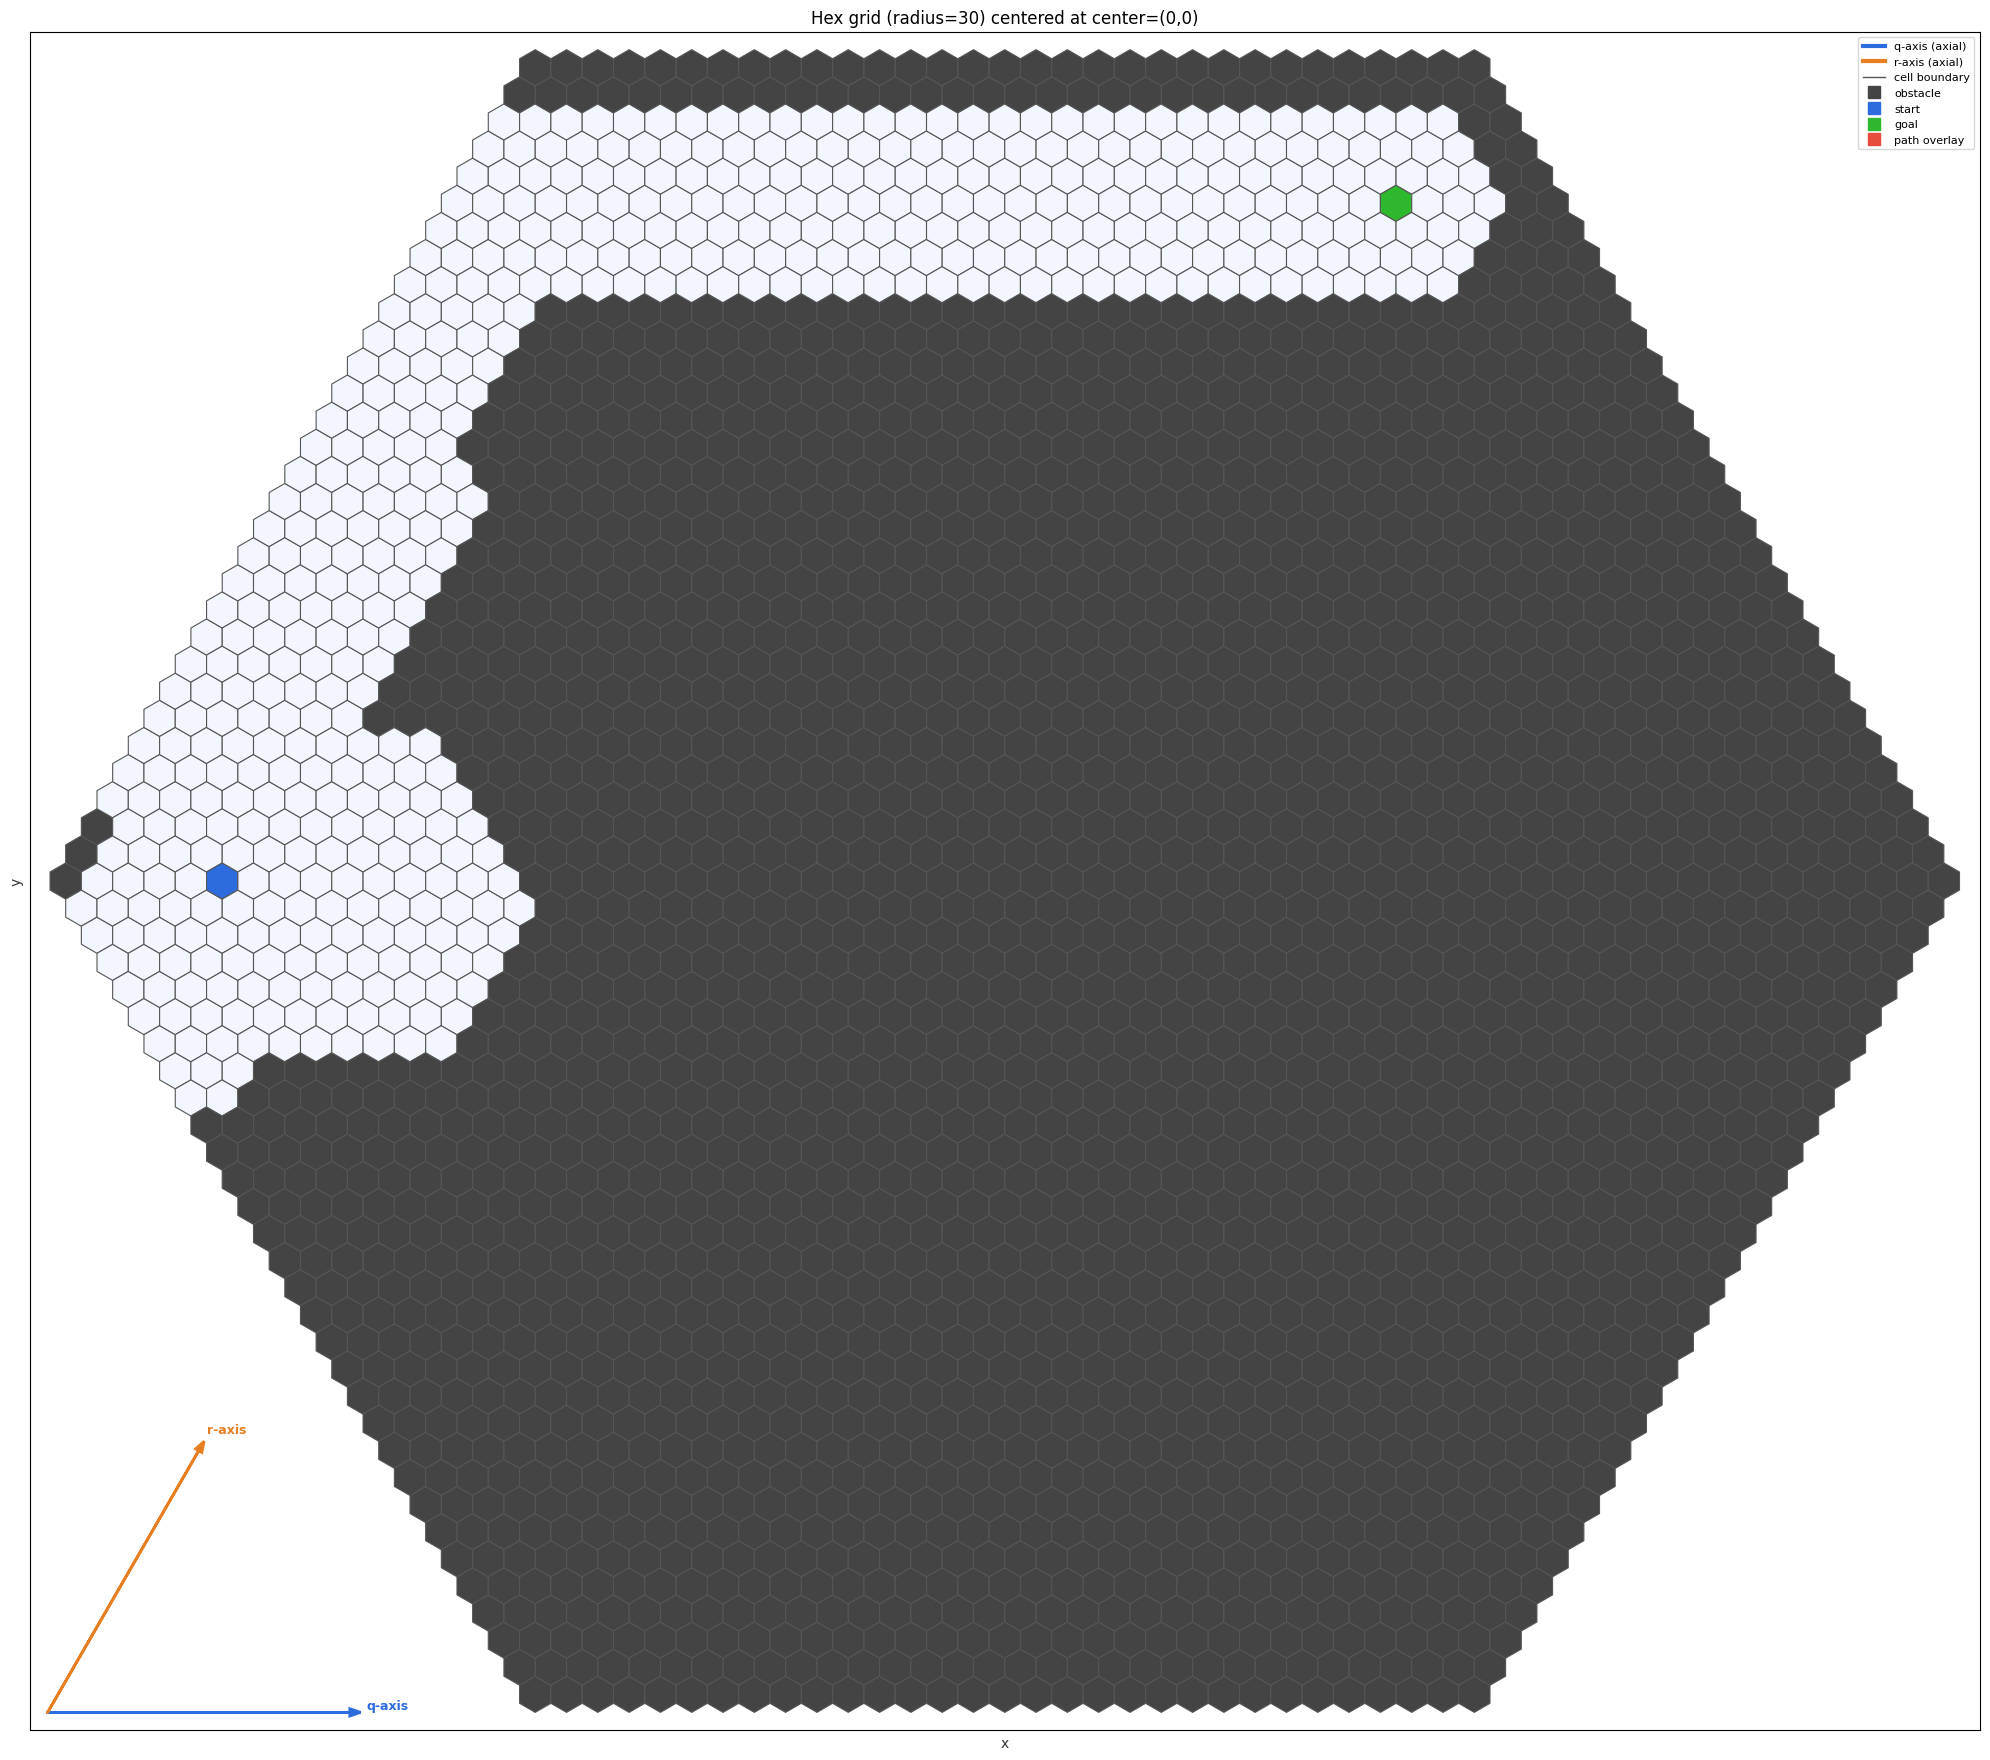

In [44]:
plot_hex_grid(
    obs,
    start,
    HexCoord(0,0),
    RADIUS,
    goal = goal,
    figsize=(20,20),
    show_coords = False,
    #path = [s.location for s in fsolution],
)


In [45]:
hs = HStarSearch(
    problem = problem,
    heuristic = h_cost_travel_time
)

fsolution = hs.search()



In [46]:
hs = HStarSearch(
    problem = problem,
    heuristic = h_cost_travel_time
)

fsolution = hs.search()
print(f'Solution found with cost {fsolution[-1].g_cost}')
print(f'Final v: {fsolution[-1].velocity.magnitude}')

r_problem = problem.reverse(fsolution[-1].velocity.magnitude)

# velocity_goal = velocity_max = 
# agent -> approaches a sharp turn
# backtracking will correct the velocity all the way until it reaches a reasonable value

# velocity is 100000
# reach a sharp turn
# velocty at turn needs to be 6
# backtrack to 100000 => 12
# 12 ~ end velocity for the forward search (hopefully)


print(f'-----\nStarting reverse search\n-----')
hs = HStarSearch(
    problem = r_problem,
    heuristic = h_cost_travel_time
)

rsolution = hs.search()
print(f'Solution found with cost {rsolution[-1].g_cost}')


Solution found with cost 8.417587981081006
Final v: 29.149698038037194
-----
Starting reverse search
-----
Solution found with cost 18.124209193872538


In [47]:
problem

In [48]:
e = 1e-6

f_velocities = [n.velocity.magnitude for n in fsolution]
r_velocities = [n.velocity.magnitude for n in rsolution]
# Check if the velocity deltas are smaller than a floating point precision tolerance
vel_match = sum([abs(f-r) for f,r in zip(f_velocities, reversed(r_velocities))]) < e
print("Velocities matched" if vel_match else "Mismatch")

Mismatch


<Axes: title={'center': 'Hex grid (radius=30) centered at center=(0,0)'}, xlabel='x', ylabel='y'>

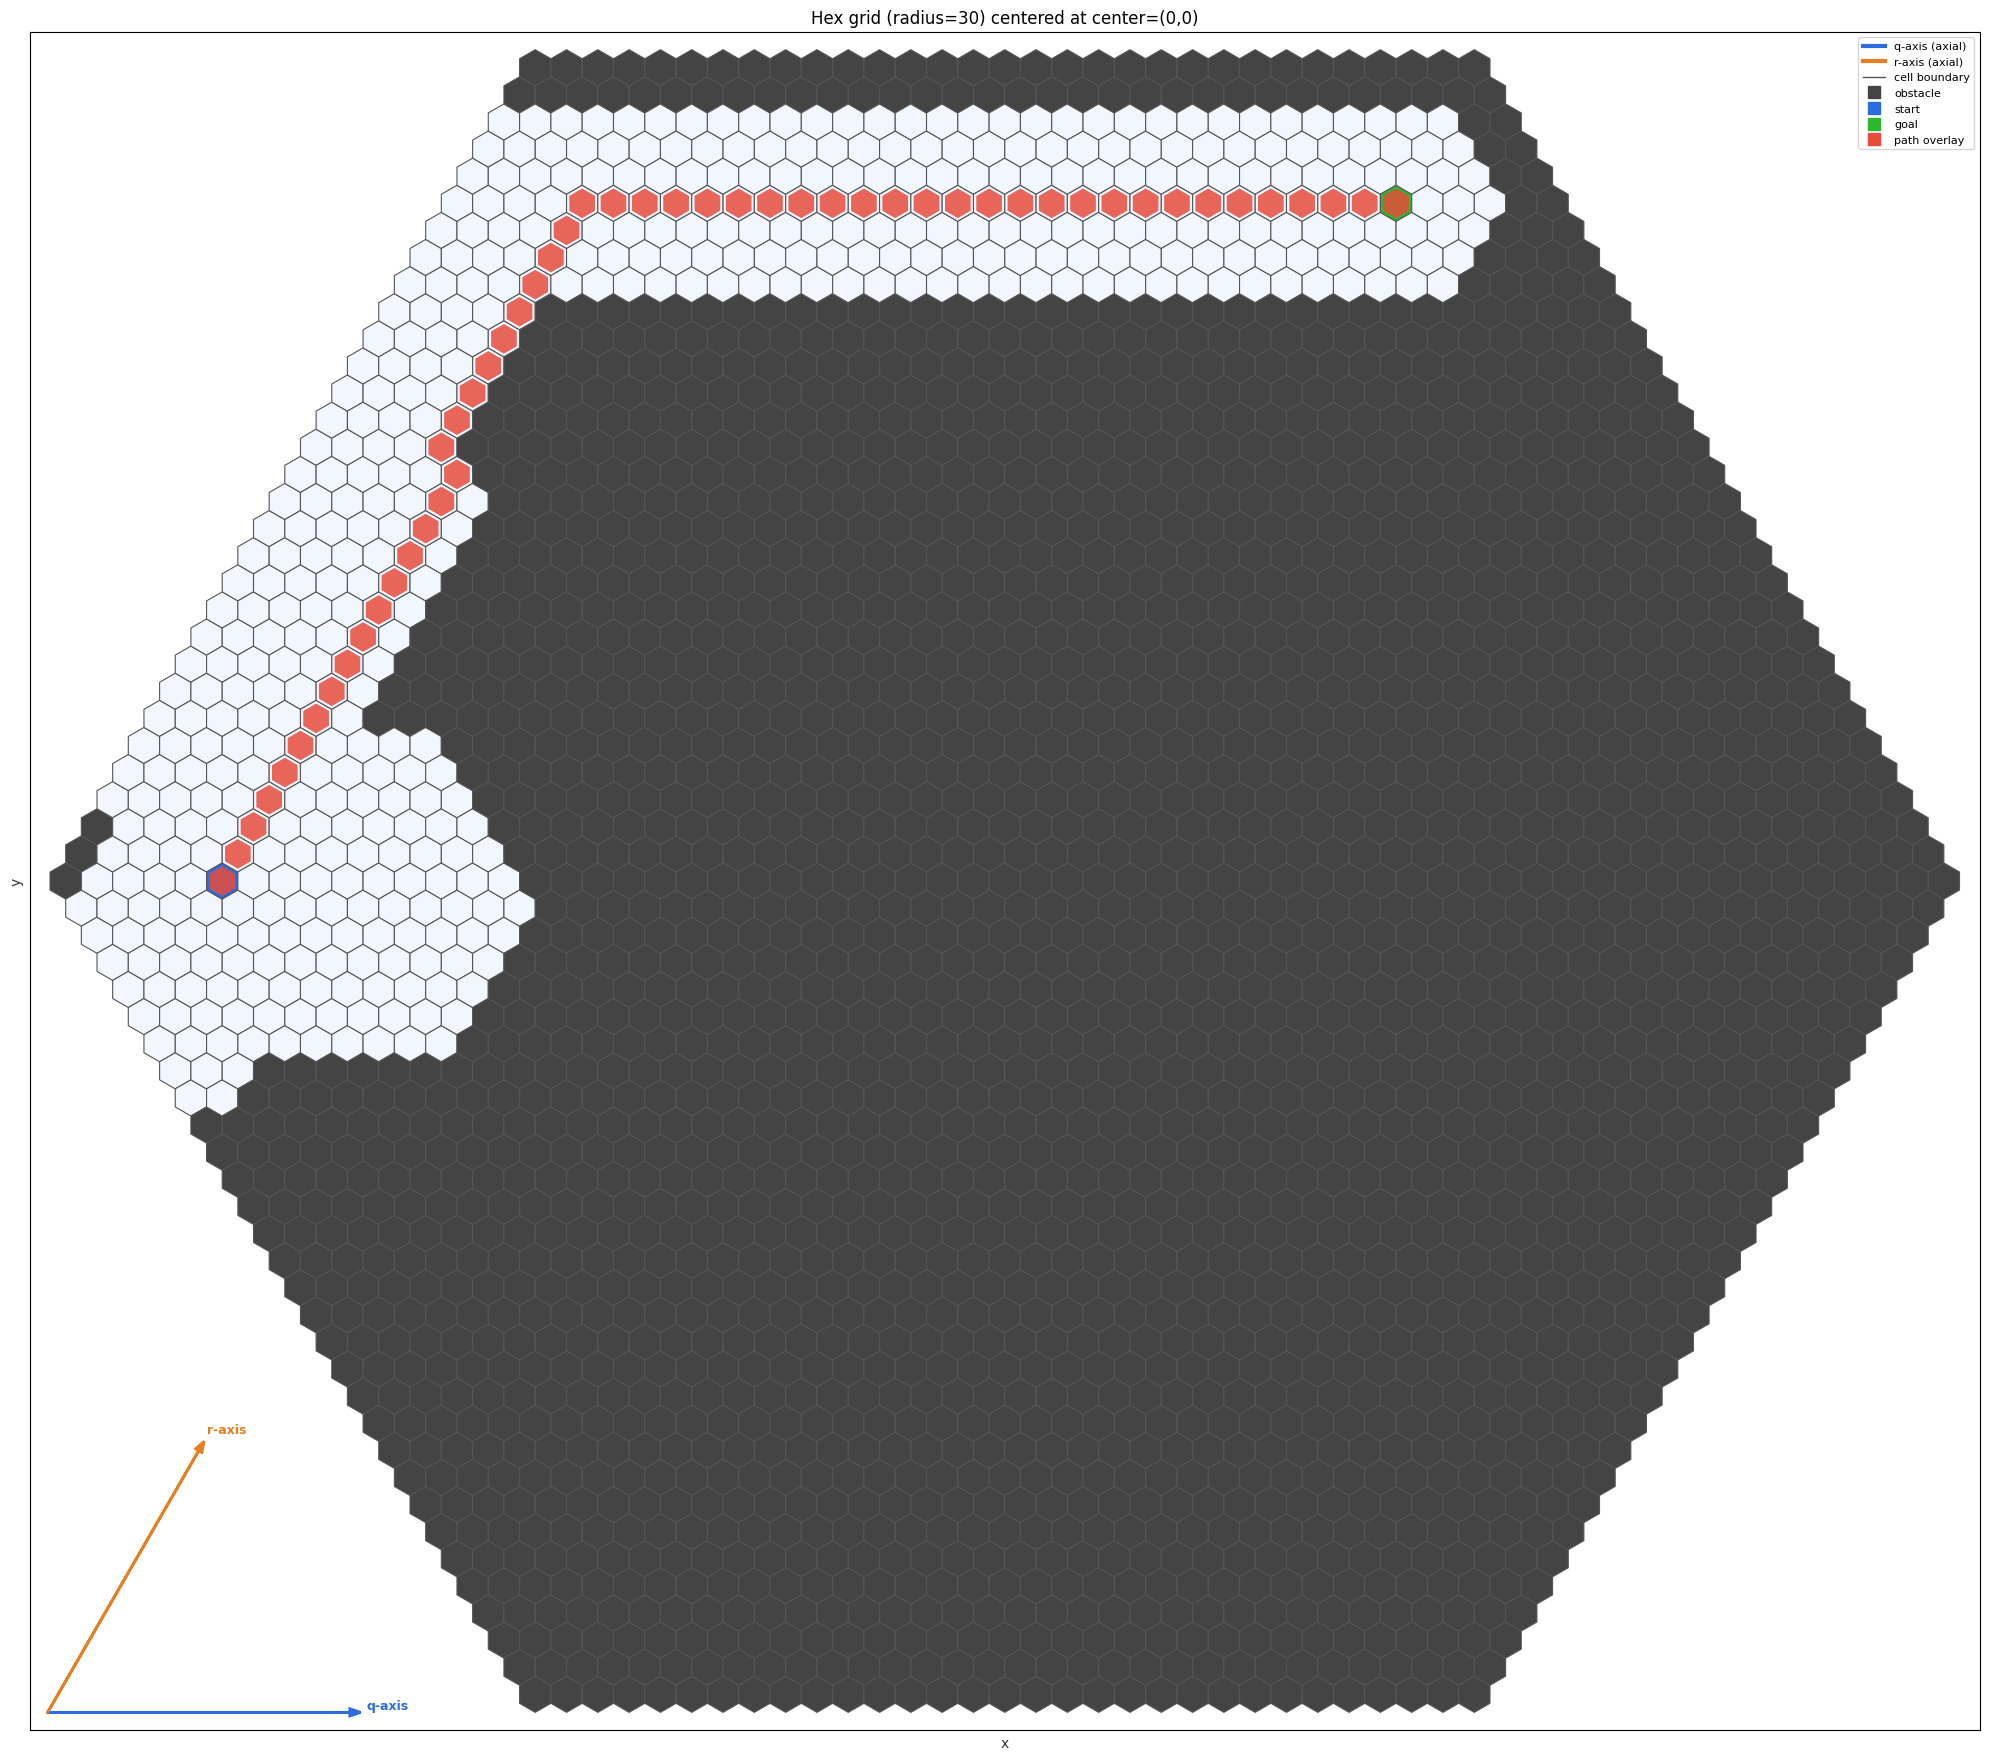

In [49]:
plot_hex_grid(
    obs,
    start,
    HexCoord(0,0),
    RADIUS,
    goal = goal,
    figsize=(20,20),
    show_coords = False,
    path = [s.location for s in fsolution],
)



<Axes: title={'center': 'Hex grid (radius=30) centered at center=(0,0)'}, xlabel='x', ylabel='y'>

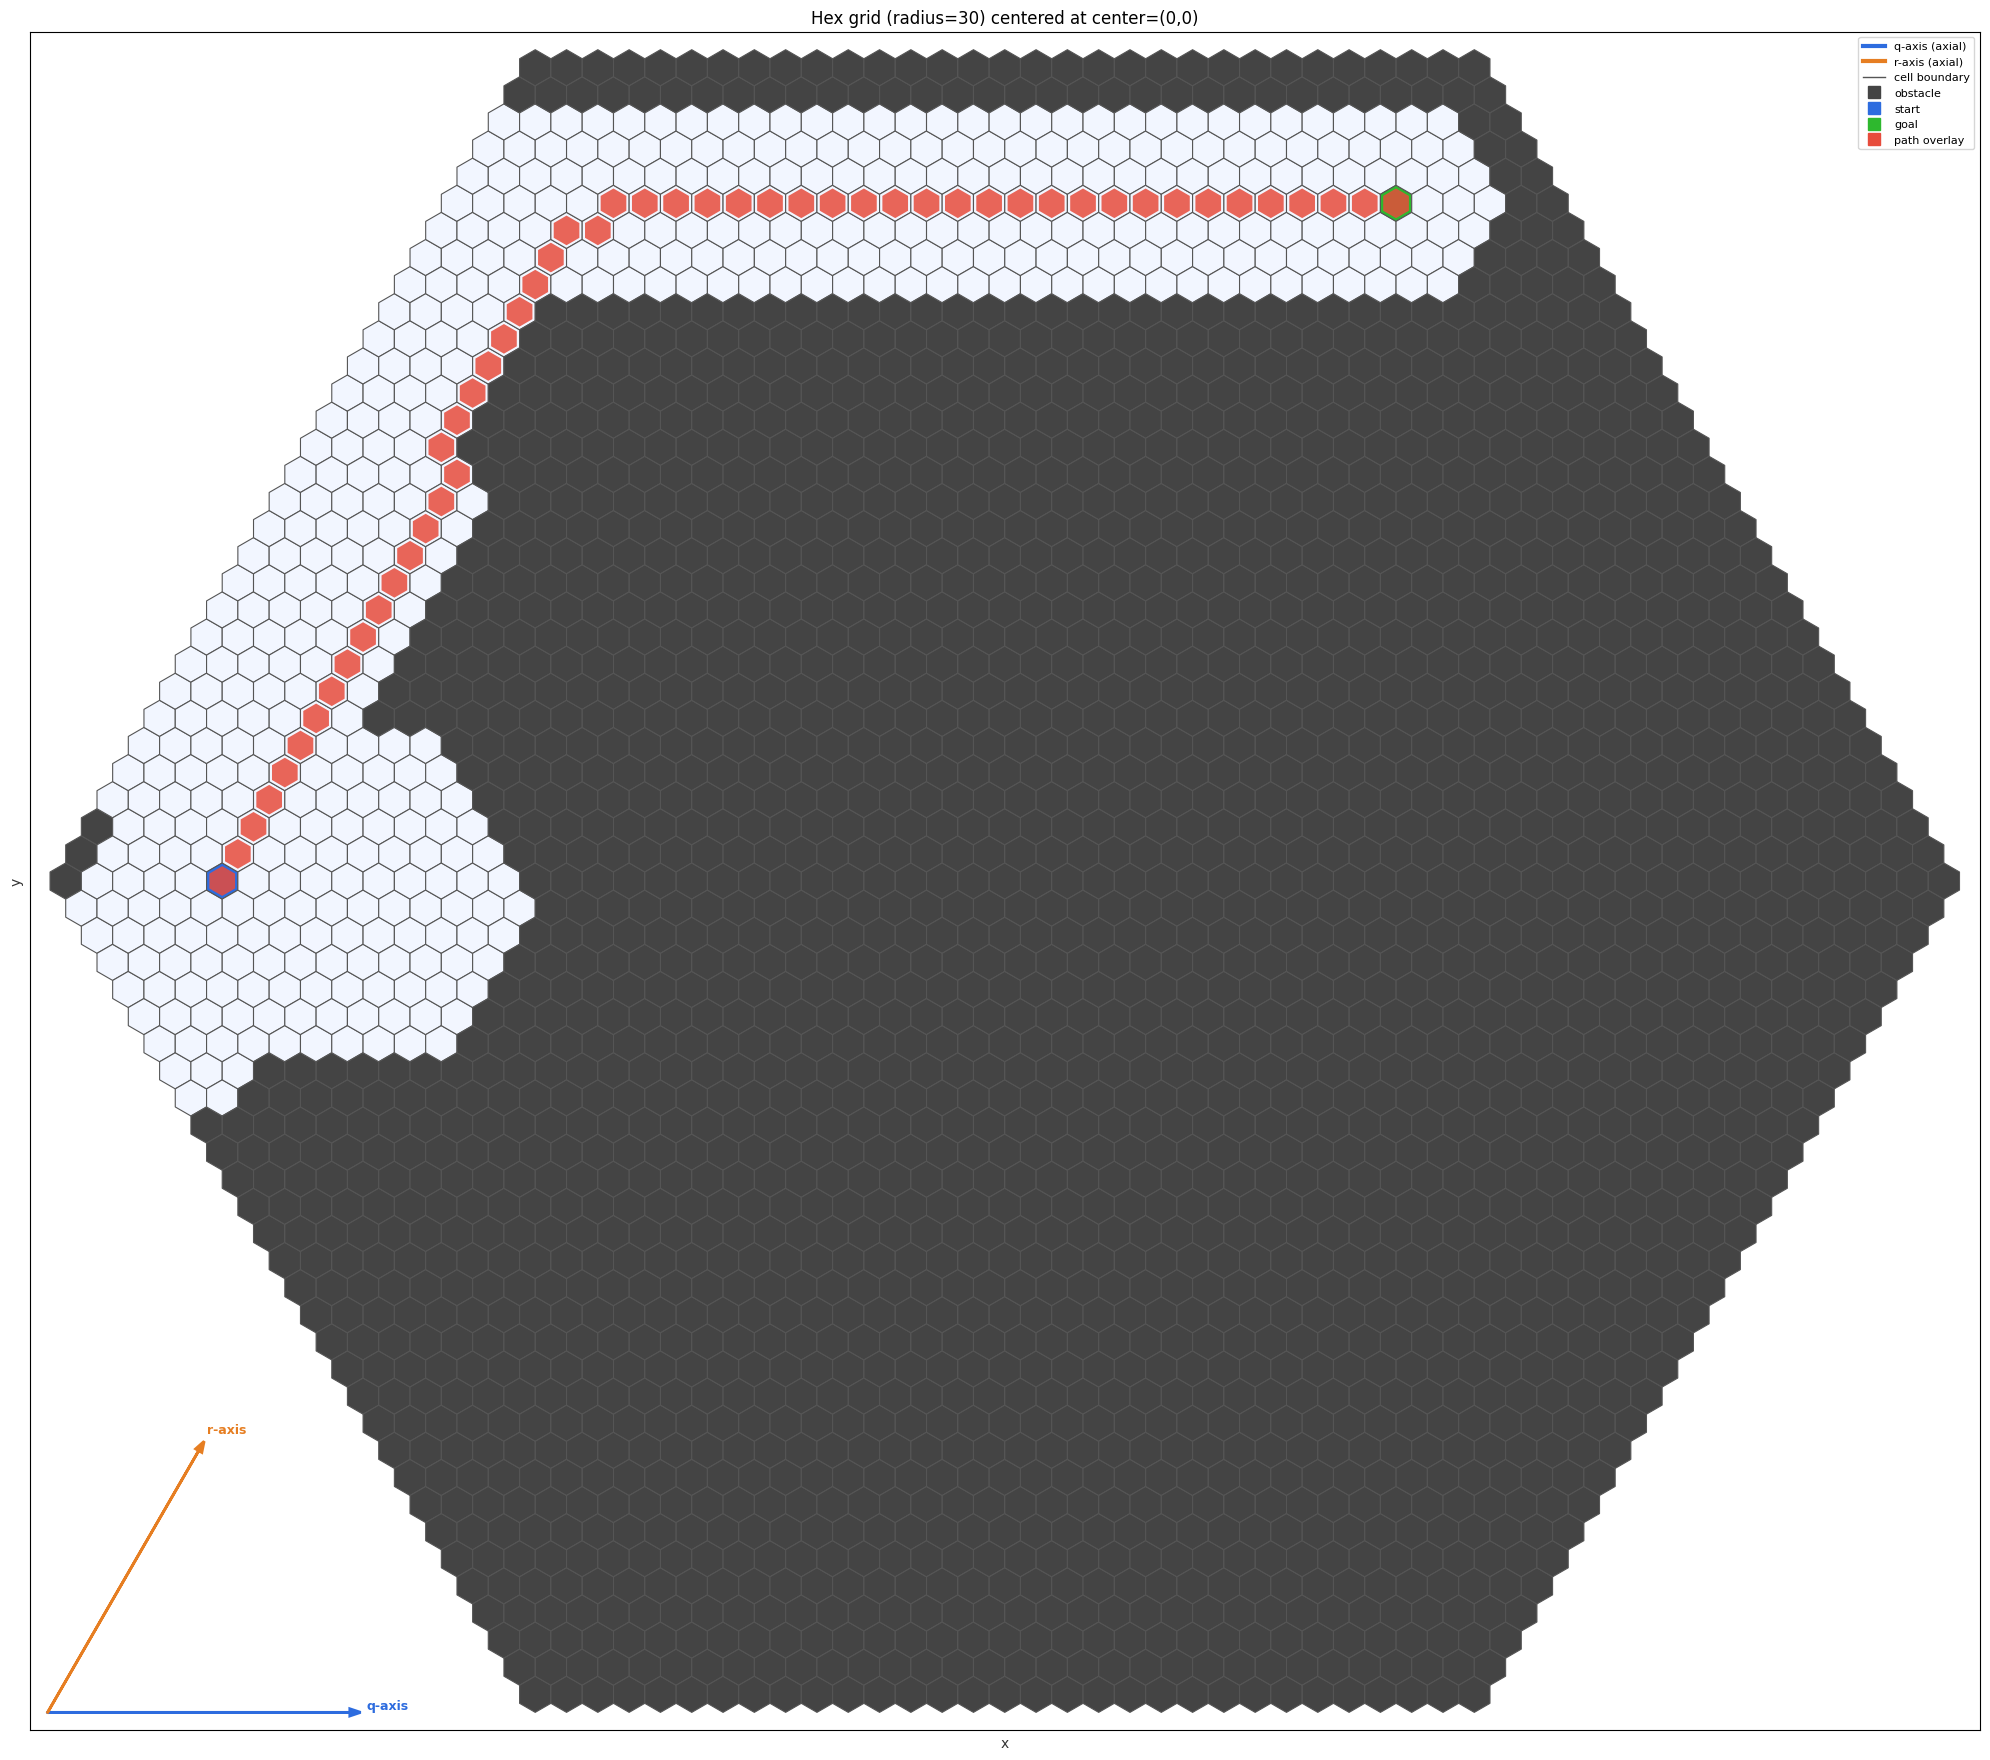

In [50]:
plot_hex_grid(
    obs,
    start,
    HexCoord(0,0),
    RADIUS,
    goal = goal,
    figsize=(20,20),
    show_coords = False,
    path = [s.location for s in rsolution],
)

In [38]:

def check_velocity_parity(problem_fwd, problem_rev, path_fwd: List[Node], path_rev: List[Node], eps=1e-9) -> bool:
    vf = [float(n.velocity.magnitude or 0.0) for n in path_fwd]          # start->goal
    vr = [float(n.velocity.magnitude or 0.0) for n in reversed(path_rev)]# goal->start (reversed)
    L = min(len(vf), len(vr))
    for i in range(L):
        if abs(vf[i] - vr[i]) > eps:
            print(f"[{i}] v_fwd={vf[i]:.12f}  v_rev={vr[i]:.12f}")
            # also show local distance & headings for this step on both sides
            def step_rows(problem, path):
                rows = []
                for k in range(1, len(path)):
                    p, c = path[k-1], path[k]
                    s  = problem._effective_step_distance(p, p.location, c.location)
                    di = get_direction(p.location, c.location)
                    rows.append((k-1, di, s, p.velocity.magnitude, c.velocity.magnitude))
                return rows
            print("FWD steps (first few):", step_rows(problem_fwd, path_fwd)[:max(3, i+2)])
            print("REV steps (first few):", step_rows(problem_rev, list(reversed(path_rev)))[:max(3, i+2)])
            return False
    print("Velocity parity: OK")
    return True


In [39]:

# 1) solve forward
fwd = HStarSearch(problem).search()
assert fwd is not None
v_goal = fwd[-1].velocity.magnitude

# 2) build reverse using the *actual* forward terminal speed
rev_problem = problem.reverse(goal_speed_mag=v_goal, goal_heading_idx=None)
rev = HStarSearch(rev_problem).search()
assert rev is not None

# 3) check
check_velocity_parity(problem, rev_problem, fwd, rev)


[1] v_fwd=1.861209718204  v_rev=0.000000000000
FWD steps (first few): [(0, 5, 1.7320508075688772, 0, 1.8612097182041991), (1, 5, 1.7320508075688772, 1.8612097182041991, 1.8612097182041991), (2, 5, 1.7320508075688772, 1.8612097182041991, 1.8612097182041991)]
REV steps (first few): [(0, 5, 1.7320508075688772, 0.0, 0.0), (1, 5, 1.7320508075688772, 0.0, 0.0), (2, 5, 1.7320508075688772, 0.0, 0.0)]


False